In [341]:
using LinearAlgebra
using Plots
using Printf

## Questão 2 )



### Letra a)

Pelo exercício 1, dado $m \geq  d + 1$, podemos garantir que $L_X$ possui posto completo, o que implica que $L_X$ é uma transformação injetiva. Ou seja, garantimos que suas inversas são inversas à esquerda. 

Sabemos que "$R_{X,d} \circ L_X = id_\mathcal{P_d}$ somente se $R_{X,d} \circ L_X(p) = p$ para todo $p \in \mathcal{P_d}$"

Pela definição, sabemos que $R_{X,d}(L_X(p)) = \argmin_{q \in \mathcal{P}_d}\|L_X(q) - L_X(p)\|^2_2$. Isso é minimizado quando $$\|L_X(q) - L_X(p)\|^2_2 = 0$$, o que acontece quando $L_X(q) = L_X(p)$. Porém, como $L_X$ é injetiva, $p = q$. Assim, para todo $p \in \mathcal{P_d}$, $R_{X,d} \circ L_X(p) = p$ provando que $R_{X,d}$ é inversa à esquerda de $L_X$.



### Letra b)

Sabemos que $m \geq d + 1$, o que implica que a matriz de $L_X$ terá dimensões $m \times (d+1)$. Seja A a matriz associada a $L_X$, o problema $R_{X,d}(L_X(p)) = p$, com $L_x(p) = b$ é por definiçaõ o problema de mínimos qudrados. Dessa forma, envolve encontrar 

$$ Ap = b \rightarrow A^TAp = A^Tb \rightarrow p = (A^TA)^{-1}A^Tb$$

Como $A$ tem posto completo, o que garantimos pelo exercício 1, então $A^TA$ também, e portanto $A^TA$ é quadrada e inversível. Assim $R_{X,d}(b) = (A^TA)^{-1}A^Tb$ é uma aplicação de uma matriz sobre um vetor, o que é uma transformação linear.

### Letra c)

Sabemos que na base canônica de $\mathcal{P_d}$, $\lbrace 1, x, x^2 \dots x^d \rbrace$, nossa matriz $L_X$ se torna a matriz de Vandermonde retangular, já que sabemos que $m \geq d + 1$.


$$ \textit{Matriz de Vandermonde (V)} :
\begin{bmatrix}
1 & x_1 & x_1^2 & \dots & x_1^d \\
1 & x_2 & x_2^2 & \dots & x_2^d \\
\vdots & \vdots & \vdots & \vdots & \vdots \\
1 & x_m & x_m^2 & \dots & x_m^d 
\end{bmatrix}
$$

Como vimos no item $b$, a solução de mínimos quadrados é $p = (A^TA)^{-1}A^Tb$. Portanto, podemos calcular $R_{X,d}$ como a pseudo-inversa de $L_x$. Assim,

$$ R_{X,d} = (V^TV)^{-1}V^T$$

é a matriz associada a $R_{X,d}$ na base canônica de $\mathcal{P}_d$. 


### Letra d )

A questão pede para escolhermos alguns valores de $m =$ #$X$ e $d$ e estudar qual o comportamento do condicionamento de $L_X$ e $R_{X,d}$ na base canônica $\mathcal{P_d}$, ou seja, $L_X$ é uma matriz de Vandermonde retangular e $R_{X,d}$ sua pseudo-inversa, quando $m$ e/ou $d$ aumentam.

Primeiramente, vamos provar que o condicionamento das matrizes associadas a $L_X$ e $R_{X,d}$ é igual. Seja A a matriz associada a $L_X$ então a matriz associada a $R_{X,d}$ é a pseudo-inversa de A. Por definição, o condicionamento de uma matriz retangular com $m \geq n$ e posto completo é definido em termos da sua pseudo-inversa, logo, igual a norma da $A$ vezes a norma da sua pseudo-inversa.

$$ \kappa (A) = \| A \| \|A^+\|$$

Seja $A = \hat{U} \hat{\Sigma} V^T$ a SVD reduzida de $A$, então a SVD reduzida de $A^+$ é $A^+A = I \rightarrow A^+\hat{U} \hat{\Sigma} V^T = I \rightarrow A^+ = V \hat{\Sigma}^{-1} \hat{U}^T$.

Portanto, o maior valor singular de $A$ é $\sigma_1$ e o menor é $\sigma_{d+1}$, e os de $A^+$ são $\frac{1}{\sigma_{d+1}}$ e $\frac{1}{\sigma_1}$.

Dessa forma, sabemos também que o condicionamento de uma matriz quando utilizado a norma 2 pode ser expresso como

$$ \kappa (A) = \frac{\sigma_{máx}}{\sigma_{mín}}$$

Logo, $\kappa (A) = \kappa (A^+) = \frac{\sigma_{1}}{\sigma_{d+1}}$.

Apesar disso, nesse curso, já percebemos que algumas coisas, às vezes, não se comportam da forma que queremos, portanto, vamos testar o que acontece com a pseudo-inversa também.

In [342]:
function createVandermonde(vetor, d)
    Vandermonde = vetor .^ (0:d)'
    return Vandermonde
end    

function evalConditionVandermonde(m, d; inversa= false)
    vetor = LinRange(-1,1,m)
    V = createVandermonde(vetor, d)
    if inversa
        return (cond(pinv(V)))
    else
        return cond(V)
    end
end

evalConditionVandermonde (generic function with 1 method)

In [343]:
function plot_condition_evaluated(m, d; variate_m = true, variate_d = false, logscale= false)
    if variate_m && !variate_d
        x = (d+1):100:m
        y = [evalConditionVandermonde(i, d) for i in x]
        y_ = [evalConditionVandermonde(i, d, inversa= true) for i in x]

        if logscale
            p = plot(x, y, label= "Vandermonde", xlabel= "m", ylabel= "condition", title= "d fixed = $d, m ascending", yscale= :log10)
            plot!(p, x, y_, label= "Pseudo-inversa")
            display(p)
        else
            p = plot(x, y, label= "Vandermonde", xlabel= "m", ylabel= "condition", title= "d fixed = $d, m ascending")
            plot!(p, x, y_, label= "Pseudo-inversa")
            display(p)
        end
        
    elseif !variate_m && variate_d
        x = 1:d
        y = [evalConditionVandermonde(m, j) for j in x]
        y_ = [evalConditionVandermonde(m, j, inversa= true) for j in x]

        if logscale
            p = plot(x, y, label="Vandermonde", xlabel= "d", ylabel= "condition", title= "m fixed = $m, d ascending", yscale= :log10)
            plot!(p, x, y_, label= "Pseudo-inversa")
            display(p)
        else
            p = plot(x, y, label= "Vandermonde", xlabel= "d", ylabel= "condition", title= "m fixed = $m, d ascending")
            plot!(p, x, y_, label= "Pseudo-inversa")
            display(p)
        end
    end
end

plot_condition_evaluated (generic function with 1 method)

Apenas $m$ aumentando

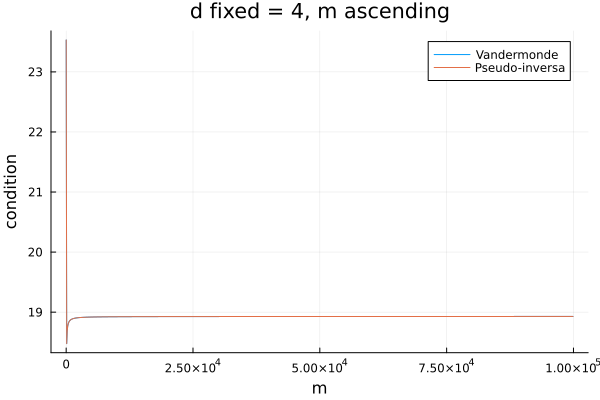

In [344]:
plot_condition_evaluated(100000, 4, variate_m= true, variate_d= false)


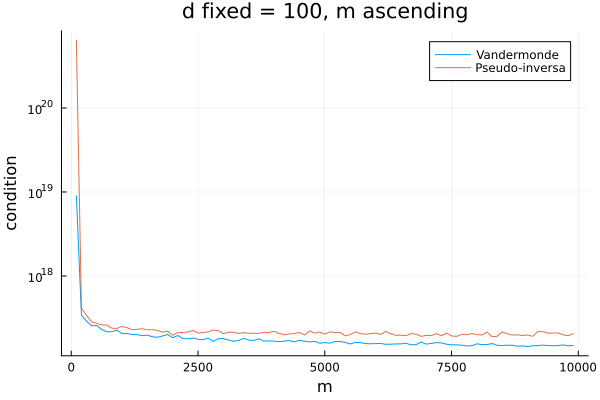

In [345]:
plot_condition_evaluated(10000, 100, variate_m= true, variate_d= false, logscale = true)

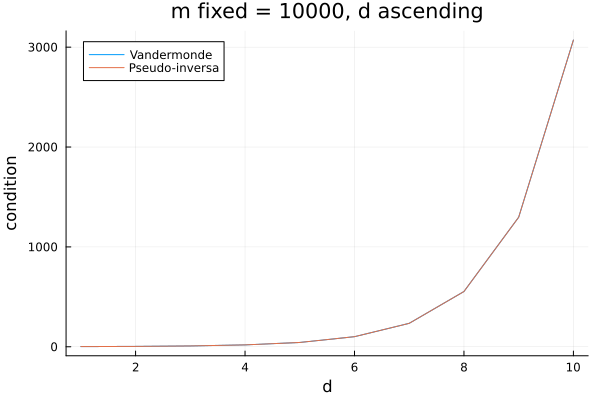

In [346]:
plot_condition_evaluated(10000, 10, variate_m= false, variate_d= true)

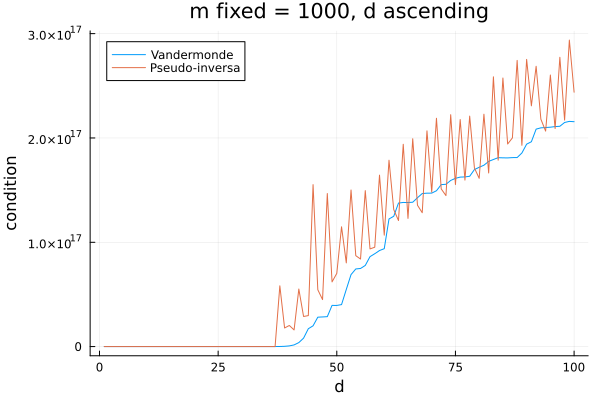

In [347]:
plot_condition_evaluated(1000, 100, variate_m= false, variate_d= true)


Podemos conferir que aumentar o número de pontos avaliados diminui o condicionamento até um ponto em que aparentemente ele atinge certa estabilidade. Portanto, o contrário também deve ser válido, aumentar o grau do nosso polinômio piora o condicionamento. 

### Letra e)

#### Calculando as Matrizes

Sabemos que a matriz de Vandermonde realiza a avalização de um polinômio da base canônica em um ponto $x_i$. Trocando da base cancônica para a base dos polinômios interpoladores de Lagrange, sabemos que 

$$p_i(x_j) = \delta_{ij},  \space \space 
 \delta{ij} =\begin{cases}
                1, i=j \\
                0, i \neq j
                \end{cases}
$$

Assim, ao avaliar um polinômio que é a combinação linear dos polinômios da base em um ponto $x_j$ (linha $j$), aparecerá apenas a parte do polinômio relacionada àquela linha. Logo, $L_X$ na base de Lagrange é

$$A =
\begin{bmatrix}
I_{d+1 \times d+1} \\ 0_{m - (d+1) \times d+1}
\end{bmatrix}

\Longrightarrow 

(L_X)_{ij} = \begin{cases}
                1, i=j \\
                0, i \neq j
                \end{cases}
$$

* Essa base foi calculada com $p_i(x) = \prod_{\substack{j=0 \\ j \neq i}}^{n} \frac{x - x_j}{x_i - x_j}$, fazendo com que não tivesse lixo, diferente da interpolação utilizada para provar que $L_X$ tem posto completo.

Assim, $R_X,d$ nessa nova base tem a mesma fórmula que na base antiga $R_{X,d}(b) = (A^TA)^{-1}A^Tb$. Portanto, 

$$ (A^TA)^{-1}A^T = \begin{bmatrix}
I_{(d+1) \times (d+1)} \space \space 0_{(d+1) \times m - (d+1)}
\end{bmatrix}$$

#### Condicionamento

Sabemos que os valores singulares de uma matriz $A$ são iguais a raiz dos autovalores de $A^TA$. Dessa forma, $$A^TA = \begin{bmatrix}
I_{(d+1) \times (d+1)} \space \space 0_{(d+1) \times m - (d+1)}
\end{bmatrix}\begin{bmatrix}
I_{d+1 \times d+1} \\ 0_{m - (d+1) \times d+1}
\end{bmatrix} = \begin{bmatrix}
I_{d+1 \times d+1} 
\end{bmatrix}$$

Como seus autovalores são $1$, então os valores singulares de $A$ são também iguais a $1$ e, portanto, o condicionamento da matriz $A$

$$\kappa (A) = \kappa(A^+) = 1$$

Assim, o condicionamento de $L_X$ e $R_{X,d}$ na base dos polinômios de Lagrange é igual a $1$.

### Letra f)

#### Base Canônica
Para calcular $L_X$ na base canônica, ou seja, para calcular a matriz de Vandermonde é necessário para cada linha $d - 1$ multiplicações para encontrarmos cada entrada, assim, para as $m$ linhas, nós encontramos uma complexidade $O(md)$.

#### Base de Lagrange
Nós podemos usar do fato de que nós já conhecemos a contrução de ambas as matrizes $L_X$ e $R_{X,d}$, respectivamente:

$$\begin{bmatrix}
I_{d+1 \times d+1} \\ 0_{m - (d+1) \times d+1}
\end{bmatrix}
\space \space \space \space \space \space\space \space \space
\begin{bmatrix}
I_{(d+1) \times (d+1)} \space \space 0_{(d+1) \times m - (d+1)}
\end{bmatrix}
$$

Portanto, a complexidade para calcular ambas é $O(1)$. Assim como o condicionamento dessas matrizes é $\kappa = 1$.

## Questão 3 )

### Letra a )

Sabemos que $R_{X_d}: \mathbb{R}^m \rightarrow \mathcal{P}_d$, $R_{X,d} \circ L_X = id_{\mathcal{P}_d}$, o que significa que para todo $p \in \mathcal{P}_d$ existe um vetor $b = L_X(p) \in \mathbb{R}^m$ tal que $R_{X,d}(b) = p$. Portanto, $R_{X,d}$ é sobrejetora e $Im(R_{X,d}) = \mathcal{P}_d$, o que implica que o posto de $R_{X,d}$ é $dim(Im(R_{X,d})) = d+1$.

Sabemos também que $L_Y$ tem posto completo e, logo, seu posto é $\min \lbrace n, d+ 1 \rbrace$

Além disso, sabemos que a transformação $(L_Y \circ R_{X,d})(b)$ é definida como $LY(R_{X,d}(b))$, e, portanto, a entrada de $L_Y$ é a saída de $R_{X,d}$, o que implica que quem vai determinar o posto da transformação é $L_Y$. Logo, o posto da transformação é $\min \lbrace n, d+ 1 \rbrace$.



### Letra b )



### Letra c )

Vamos voltar a definição do funcional de avaliação, quando restrito ao $\mathcal{P}_d$, 

$$ L_X: \mathbb{R}^m \rightarrow \mathcal{P}_d, \space \space \space \space L_X(p) = ( p(x_1) , \dots , p(x_m))$$

Dessa forma, ao tomarmos $b \in \mathbb{R}^m$ e aplicarmos $R_{X,d}(b) = p$, essa transformação nos retorna o melhor polinômio $p$ que nos retorna $p(x_i) = b_i$. Ao aplicarmos, $L_Y$ sobre o nosso polinômio resultante $p$, então nós obtemos $L_Y(p) = (p(y_1), \dots , p(y_n))$. Ou seja, nós avaliamos os valores de $Y$ no polinômio $p$ no mesmo intervalo conhecido $[-1,1]$. Ou seja, nós interpolamos $Y$ no polinômio $p$.

### Letra d )

In [348]:
function createLagrange(X, Y, d)
    nodes = X[1:d+1]
    n = length(Y)
    L = zeros(n, d+1)

    w = [1/prod(nodes[j] - nodes[k] for k in 1:(d+1) if k != j) for j in 1:(d+1)]

    for i in 1:n
        l = prod(Y[i] - nodes[j] for j in 1:(d+1))
        for j in 1:(d+1)
            if Y[i] == nodes[j]
                L[i,j] = 1.0
            else
                L[i,j] = l * (w[j]/ (Y[i] - nodes[j]))
            end
        end
    end
    return L
end

createLagrange (generic function with 1 method)

In [349]:
function compare_bases(m, n, d; plot_flag= false, Chebyshev= false, return_values= false)
    if Chebyshev
        X = [cos((2i - 1) / (2m) * π) for i in 1:m] 
    else
        X = LinRange(-1, 1, m)
    end

    Y = LinRange(-1, 1, n)

    L = createLagrange(X, Y ,d) * pinv(createLagrange(X, X ,d))
    V = createVandermonde(Y,d) * pinv(createVandermonde(X,d))

    sigmaL = svdvals(L)
    sigmaC = svdvals(V)
    
    if return_values
        return L, V, sigmaL, sigmaC
    else
        println("|| L - V ||: ", norm(L-V))
        println("Valores Singulares Lagrange: ", sigmaL)
        println("Valores Singulares Vandermonde: ", sigmaC)
        if plot_flag
            plot(1:length(sigmaL), sigmaL, label= "Lagrange", marker= :circle, title= "Valores Singulares", yscale= :log10, size= (300,300))
            plot!(1:length(sigmaC), sigmaC, label= "Vandermonde", marker= :circle)
        end
    end
end

compare_bases (generic function with 1 method)

|| L - V ||: 0.00015595933747477938
Valores Singulares Lagrange: [3.5950513927725214, 2.8923520290741918, 1.8503939646407341, 1.848685863250245, 1.8476491935861032, 1.8476454397285753, 1.8476452953354834, 1.8476452865143231, 1.8476452115719617, 1.8476436647722478, 1.847638048297782, 1.847604785637709, 1.805872102186872, 1.7723854025903507, 1.037197607127558, 1.0269727665703834, 1.6142396014446054e-5, 9.397720343756132e-6, 3.58428589584356e-6, 2.264677555374724e-6, 1.091316132532751e-6, 5.371465481656967e-7, 3.104103977161073e-7, 2.793231949569514e-7, 2.1488671799358083e-7, 1.124184607039324e-7, 6.844269444441246e-8, 3.236490968058289e-8, 1.9673154900794945e-8, 1.1683979558163412e-8]
Valores Singulares Vandermonde: [3.5950526552897575, 2.8923420580523156, 1.8503960166311892, 1.8486815879867375, 1.8476454754125782, 1.8476453193317184, 1.8476452861544355, 1.847645286154321, 1.8476452861171, 1.8476452857731354, 1.8476359886779024, 1.8476106694896517, 1.805877534041999, 1.7723824272851898, 

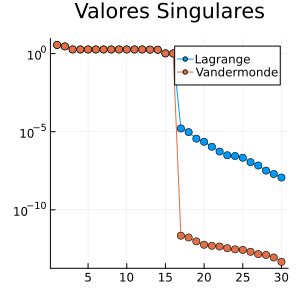

In [350]:
compare_bases(30, 100, 15; plot_flag= true, Chebyshev= false, return_values= false)

|| L - V ||: 5.8309975803216165
Valores Singulares Lagrange: [1.7129092488848, 1.4215935887740303, 1.4214149049080986, 1.421410684680199, 1.4214055998821433, 1.4116184007553465, 1.0109019912720976, 0.00010392224931429496, 8.541992988319012e-5, 2.3040007047748083e-5, 1.9418642277946413e-5, 1.039262960882936e-5, 6.355384401809402e-6, 4.103428710035846e-6, 2.258754557174233e-6, 1.7336052426564865e-6, 1.2026765535177427e-6, 6.293083714400458e-7, 4.2678487668448475e-7, 2.3021483188792603e-7, 1.9833626048919332e-7, 8.253389156440588e-8, 4.2936753589269486e-8, 3.522230445688283e-8, 9.703395292161127e-9, 1.9591206014603364e-9, 2.6126010433627833e-10, 1.8950887402796864e-10, 5.494402621359965e-11, 2.4178156895820094e-12, 5.618851126608709e-14, 4.0893894642049835e-14, 1.6361460187736032e-14, 8.511454314622897e-15, 5.72992592488486e-15, 4.242684896051878e-15, 2.2126727715995066e-15, 5.799018061559896e-16, 2.674134406895892e-16, 2.0559029021542325e-16, 1.3994852527221944e-16, 6.136812087902332e-17

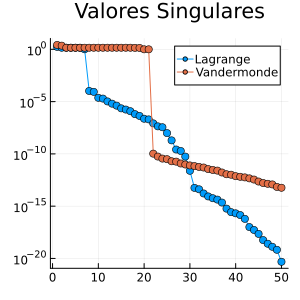

In [351]:
compare_bases(50, 100, 20;  plot_flag= true, Chebyshev= false, return_values= false)

|| L - V ||: 5416.046337655497
Valores Singulares Lagrange: [11.14298116633217, 1.4624292039656126, 1.4214237043192197, 1.4201944449591528, 1.1472129965590543, 1.0000474338427896, 9.421173005485379e-6, 6.89392723164033e-7, 2.387225322007369e-7, 7.651400420038393e-8, 1.3405118997059143e-8, 8.645137351717961e-10, 3.7450440382338743e-11, 3.148090697655753e-12, 5.501970556420229e-13, 2.4065961726211375e-17, 1.0954898515226035e-18, 4.100968206511282e-19, 6.748640865446458e-20, 1.8387133836588543e-20, 5.475201112407114e-21, 1.586094142901041e-21, 4.152384973786492e-22, 1.562613654138184e-22, 4.911019003358568e-23, 1.1499016369821584e-23, 2.0900948932152856e-24, 4.580286814025876e-25, 2.5896286928558893e-25, 5.008134862740722e-26, 2.983565143632056e-26, 1.2641828996372491e-26, 3.200024100957323e-27, 2.7162461565202966e-27, 4.4161336749866e-28, 3.735199822945315e-28, 1.2306877304824446e-28, 3.3399456645604533e-29, 2.624157814690388e-29, 5.770847360080603e-30, 5.247581934772398e-30, 3.119665646

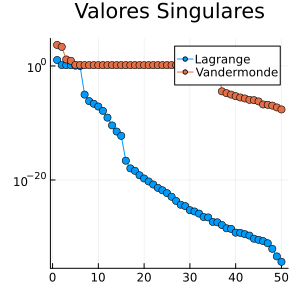

In [352]:
compare_bases(50, 100, 35; plot_flag= true, Chebyshev= false, return_values= false)

Podemos perceber que, assim como nós descobrimos na letra b, a composta não depende da base, mas nossas matrizes se tornam diferentes a medida que aumentamos o grau do nosso polinômio.

## Questão e )

In [391]:
function evalConditionBases(m, n, d; logscale= false, lim_x = (-1,1), lim_y= (-1,1))
    x1, x2 = lim_x
    y1, y2 = lim_y

    X = LinRange(x1, x2, m)
    Y = LinRange(y1, y2, n)
    
    if logscale
        println("Condicionamento Composta Lagrange(log): ", log10(cond(createLagrange(X, Y ,d) * pinv(createLagrange(X, X ,d)))))
        println("Condicionamento Composta Vandermonde(log): ", log10(cond(createVandermonde(Y,d) * pinv(createVandermonde(X,d)))))
    else
        println("Condicionamento Composta Lagrange: ", cond(createLagrange(X, Y ,d) * pinv(createLagrange(X, X ,d))))
        println("Condicionamento Composta Vandermonde: ", cond(createVandermonde(Y,d) * pinv(createVandermonde(X,d))))
    end
end

evalConditionBases (generic function with 1 method)

In [384]:
function plot_condition_evaluated_bases(m, n, d; variate_n = true, variate_d = false, logscale= false, lim_x = (-1,1), lim_y= (-1,1))
    x1, x2 = lim_x
    y1, y2 = lim_y

    X = LinRange(x1, x2, m)

    if variate_n && !variate_d
        data_l = Float64[]
        data_c = Float64[]

        range = (d+1):100:n
        for i in range
            Y = LinRange(y1, y2, i)
            push!(data_l, cond(createLagrange(X, Y ,d) * pinv(createLagrange(X, X ,d))))
            push!(data_c, cond(createVandermonde(Y,d) * pinv(createVandermonde(X,d))))
        end

        p = plot(range, data_l, xlabel= "n: #Y", ylabel= "condition", title= "d fixed = $d, n ascending", label= "Lagrange")
        plot!(p, range, data_c, xlabel= "n: #Y", ylabel= "condition", title= "d fixed = $d, n ascending", label= "Canônica")

        if logscale
            plot!(p, yscale= :log10)
        end

        display(p)
        
    elseif !variate_n && variate_d
        data_l = Float64[]
        data_c = Float64[]

        range = 1:d
        for i in range
            Y = LinRange(y1, y2, m)
            push!(data_l, cond(createLagrange(X, Y ,i) * pinv(createLagrange(X, X ,i))))
            push!(data_c, cond(createVandermonde(Y,i) * pinv(createVandermonde(X,i))))
        end

        p = plot(range, data_l, label="Lagrange", xlabel= "d", ylabel= "condition", title= "n fixed = $n, d ascending")
        plot!(p, range, data_c, label= "Canônica", xlabel= "d", ylabel= "condition", title= "n fixed = $n, d ascending")

        if logscale
            plot!(p, yscale= :log10)
        end

        display(p)
    end
end

plot_condition_evaluated_bases (generic function with 1 method)

In [355]:
function plot_condition_heatmap(m, max_n, max_d; lim_x = (-1,1), lim_y = (-1,1), logscale = true)
    x1, x2 = lim_x; y1, y2 = lim_y

    X = LinRange(x1, x2, m)
    
    N_range = 0:100:max_n
    D_range = 1:max_d

    Z_lagrange = zeros(length(D_range), length(N_range)); Z_canonica = zeros(length(D_range), length(N_range))

    for (j, n) in enumerate(N_range)
        Y = LinRange(y1, y2, n)
        for (i, d) in enumerate(D_range)
            
            if d >= n
                Z_lagrange[i, j] = NaN
                Z_canonica[i, j] = NaN
            else
                mat_L = createLagrange(X, Y, d) * pinv(createLagrange(X, X, d)); mat_C = createVandermonde(Y, d) * pinv(createVandermonde(X, d))

                if logscale
                    cond_L = log10(cond(mat_L)); cond_C = log10(cond(mat_C))
                else
                    cond_L = cond(mat_L); cond_C = cond(mat_C)
                end
                
                Z_lagrange[i, j] = cond_L; Z_canonica[i, j] = cond_C
            end
        end
    end

    z_label = "Condition"
    if logscale
        z_label = "log10(Cond)"
    end
    
    
    p1 = heatmap(N_range, D_range, Z_lagrange, xlabel = "n", ylabel = "d", title = "Lagrange ($z_label)", color = :inferno, xticks= N_range)         
    p2 = heatmap(N_range, D_range, Z_canonica, xlabel = "n", ylabel = "d", title = "Canônica ($z_label)", color = :inferno, right_margin=5Plots.mm, xticks= N_range)
    display(plot(p1, p2, layout = (1, 2), size = (900, 400)))
end

plot_condition_heatmap (generic function with 1 method)

In [495]:
# Funções interessantes

function plot_interpolation(m, n, d; Chebyshev= false, lim_x = (-1,1), lim_y = (-1,1))
    x1, x2 = lim_x
    y1, y2 = lim_y

    if Chebyshev
        X = [cos((2i - 1) / (2m) * π) for i in 1:m] 
    else
        X = LinRange(x1, x2, m)
    end

    Y = LinRange(y1, y2, n)
    t = cos.(3 .* X) .+ sin.(6 .* X)

    Lx = createLagrange(X, X, d)
    Ly = createLagrange(X, Y, d)

    Vx = createVandermonde(X,d)
    Vy = createVandermonde(Y,d)


    wL = pinv(Lx) * t
    wV = pinv(Vx) * t

    y_prev_ =  Ly * wL
    y_prev =  Vy * wV

    fL = Lx * wL
    fV = Vx * wV

    range = LinRange(y1, y2, m + 50)

    plot(X, t, label="f(x) original", size= (1000,300), leg= :bottom, layout= (1,4))
    scatter!(Y, y_prev_, label="interpolado em Y", title= "Lagrange", subplot= 1)

    plot!(X, t, label="f(x) original", leg= :bottom, subplot= 2)
    scatter!(Y, y_prev, label="interpolado em Y", title= "Canônica", subplot= 2)

    plot!(X, t, label="f(x) original", leg= :bottom, subplot= 3)
    plot!(X, fL, label="polinomio de L", title= "Canônica", subplot= 3)

    plot!(X, t, label="f(x) original", leg= :bottom, subplot= 4)
    plot!(X, fV, label="polinomio de V", title= "Canônica", subplot= 4)
end


sse(y, t) = norm(y - t)^2

function calculate_error(m, n, d; Chebyshev = false, lim_x = (-1,1), lim_y = (-1,1))
    x1, x2 = lim_x
    y1, y2 = lim_y
    
    if Chebyshev
        X = [cos((2i - 1) / (2m) * π) for i in 1:m]
    else
        X = collect(LinRange(x1, x2, m))
    end
    
    Y = collect(LinRange(y1, y2, n))
    
    t_X = cos.(3 .* X) .+ sin.(6 .* X)
    t_Y = cos.(3 .* Y) .+ sin.(6 .* Y)
    
    y_prev_ = createLagrange(X, Y, d) * pinv(createLagrange(X, X, d)) * t_X
    y_prev  = createVandermonde(Y, d) * pinv(createVandermonde(X, d)) * t_X
    
    println("Erro Lagrange: ", sse(y_prev_, t_Y))
    println("Erro Vandermonde: ", sse(y_prev, t_Y))
end

calculate_error (generic function with 1 method)

In [477]:
evalConditionBases(300, 50, 10; logscale= false, lim_x = (-1,1), lim_y= (-1,1))

Condicionamento Composta Lagrange: 2.2562664624961475e18
Condicionamento Composta Vandermonde: 3.643248331093414e16


Vamos verificar, agora, se nós podemos fazer $n \rightarrow \infty$ sem prejudicar o condicionamento da matriz.

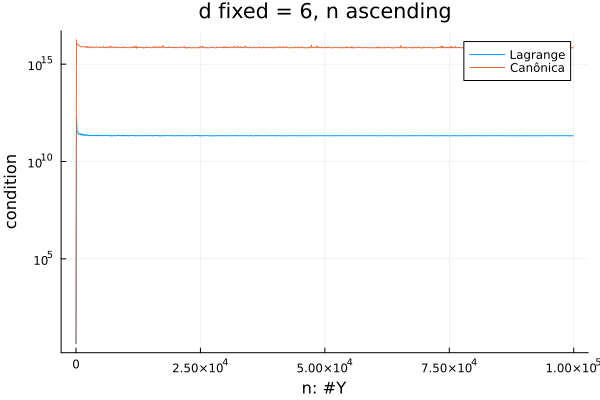

In [388]:
plot_condition_evaluated_bases(30, 100000, 6, variate_n= true, variate_d= false, logscale= true)
# plot_interpolation(20, 10000, 5)

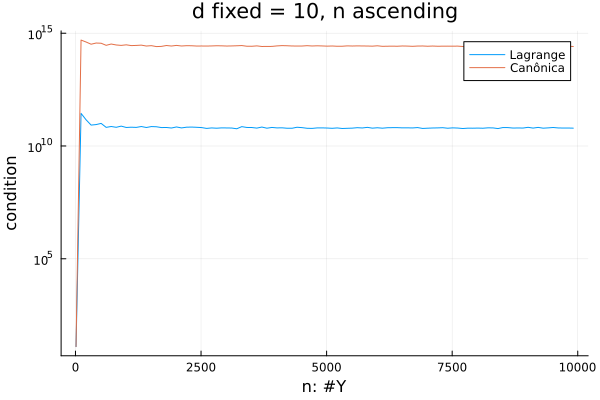

In [ ]:
plot_condition_evaluated_bases(30, 100000, 10, variate_n= true, variate_d= false, logscale= true)
# plot_interpolation(20, 10000, 10)

A partir disso, verificamos que sim, é possível variar $n \rightarrow \infty$ sem prejudicar o condicionamento da composta.

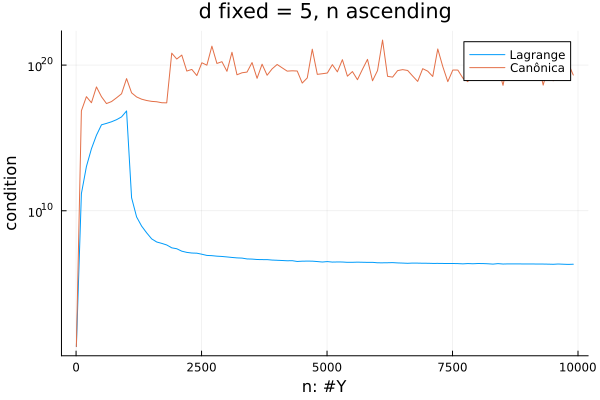

In [502]:
plot_condition_evaluated_bases(1000, 10000, 5, variate_n= true, variate_d= false, logscale= true)
# plot_interpolation(1000, 1000, 5)

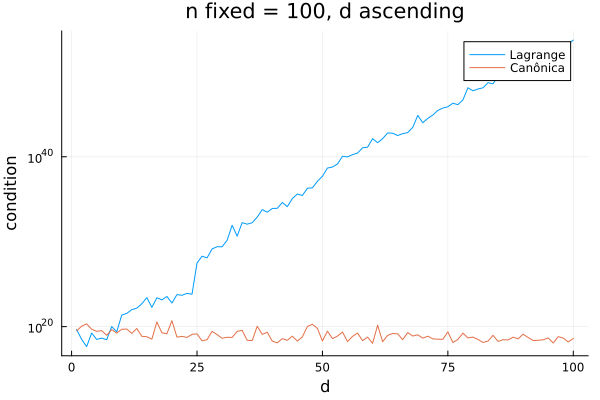

In [498]:
plot_condition_evaluated_bases(500, 100, 100, variate_n= false, variate_d= true, logscale= true)

## Questão f )

In [376]:
compare_bases(41, 10, 40)

|| L - V ||: 42772.36315951627
Valores Singulares Lagrange: [42289.58693716025, 6408.965222520013, 1.4285625768425794, 1.1809313230124567, 1.0, 1.0, 0.9573640435929076, 0.9511645600099995, 0.8770052889028572, 0.8340511261740688]
Valores Singulares Vandermonde: [83.96891240852102, 43.28768752001969, 1.004809550464501, 1.0000006947762006, 0.9999694483286427, 0.9597745922978053, 0.8243589476562798, 0.8219080206784382, 0.8035142661546169, 0.7532153058466134]


In [365]:
compare_bases(41, 10, 40, Chebyshev= true)

|| L - V ||: 0.6605642532587472
Valores Singulares Lagrange: [1.4149218840260402, 1.400986632557932, 1.0346638226054212, 1.0169545330096907, 1.011267541032545, 1.0015838035275477, 0.9988035949473527, 0.9521417378881729, 0.9521071504595762, 0.9181603459237448]
Valores Singulares Vandermonde: [1.3932013412606052, 1.3742593535835268, 1.0209769798824686, 1.010743250234859, 1.010473424902258, 0.9869028085806199, 0.9664818734569761, 0.9509443550777363, 0.9500996717450766, 0.8263767859414984]


In [366]:
compare_bases(11, 10, 10)

|| L - V ||: 2.3977480496186023e-12
Valores Singulares Lagrange: [1.977300670186517, 1.1083569341583444, 1.0000133830618065, 0.9999123578269139, 0.948977618497406, 0.948701599541265, 0.9486829538947982, 0.9450432141962619, 0.9227119899397445, 0.43809107573421735]
Valores Singulares Vandermonde: [1.9773006701855604, 1.1083569341583823, 1.0000133830617983, 0.9999123578269233, 0.9489776184973886, 0.9487015995412659, 0.948682953894802, 0.9450432141962772, 0.9227119899398021, 0.43809107573422745]


In [367]:
compare_bases(11, 10, 10, Chebyshev= true)

|| L - V ||: 3.4558085698533036e-13
Valores Singulares Lagrange: [1.4652881665001811, 1.3754343969450276, 1.1279224987584089, 1.1090508176584046, 1.07943779765889, 1.0618863568221417, 1.0024581432242519, 0.9729570693575857, 0.9534655863046255, 0.10203951259319957]
Valores Singulares Vandermonde: [1.4652881665002848, 1.3754343969449647, 1.1279224987584155, 1.109050817658439, 1.0794377976588938, 1.0618863568221595, 1.0024581432242528, 0.9729570693575916, 0.9534655863045911, 0.10203951259320175]


In [368]:
compare_bases(100, 300, 10)


|| L - V ||: 3.336789639150324
Valores Singulares Lagrange: [1.7427509606051639, 1.738414414266913, 1.7378738772277689, 1.7378734979489268, 1.7378719455353588, 1.7349282996758613, 1.4737199496406488, 0.0002454262741154503, 0.00018004547561577622, 0.00017209413643685858, 0.00015894976864509898, 0.00014961468660336128, 0.00013843167093119298, 0.00013222460707112225, 0.00012629839482291308, 0.0001203810094081832, 0.00010501645727496847, 9.67702457161367e-5, 8.865530001384752e-5, 8.628835503234869e-5, 8.108575274993243e-5, 7.616414737682794e-5, 7.488405838712606e-5, 7.160892755882167e-5, 6.993082316803126e-5, 6.364850940021576e-5, 5.750972547179483e-5, 5.568902240321838e-5, 5.3396849872879444e-5, 5.23315380869542e-5, 5.062885829336712e-5, 4.614342060156158e-5, 4.195660944771935e-5, 4.097950607691056e-5, 3.7792837608839296e-5, 3.4175958113760283e-5, 3.282818944045418e-5, 3.097056574518049e-5, 2.9071203974096053e-5, 2.8844437358218476e-5, 2.4292045510995235e-5, 2.370377934771732e-5, 2.264659

In [369]:
compare_bases(100, 300, 10, Chebyshev= true)

|| L - V ||: 4.090543708542914
Valores Singulares Lagrange: [2.1498052159029033, 2.05745832224913, 1.8299530439036502, 1.4458293960354616, 0.8163500461658044, 0.00013453674598193027, 0.00011844384783278205, 0.00011764336143973188, 0.00011126373248611122, 9.685539606610848e-5, 9.121423990733229e-5, 8.539560249196308e-5, 7.812960416351346e-5, 7.660446666569961e-5, 7.093610768424999e-5, 6.873061245115026e-5, 6.507785706227643e-5, 5.9200198445663747e-5, 5.628561571781104e-5, 5.3159870552440936e-5, 5.1831661151595195e-5, 4.897702940526215e-5, 4.596825348160199e-5, 4.26704109264018e-5, 3.9458563369050514e-5, 3.736112774435424e-5, 3.428698737698261e-5, 3.324658651577094e-5, 3.062360037517155e-5, 2.7777966421735584e-5, 2.7652804872825136e-5, 2.4980525255926083e-5, 2.3826703654912747e-5, 2.3343737397862e-5, 2.055013323593408e-5, 2.0113661873673113e-5, 1.8171648463955194e-5, 1.7452695439171905e-5, 1.616910577582563e-5, 1.5025178413881175e-5, 1.4845674598885357e-5, 1.3783314203300747e-5, 1.315587

|| L - V ||: 8.123187563563869
Valores Singulares Lagrange: [1.345305518556819, 1.2181956484695151, 1.1112325433427408, 1.0401088863963277, 0.8853810136909602, 0.4297592561074334, 1.0607113265469598e-5, 5.668615315288607e-6, 2.494944229589215e-6, 5.768425012407709e-7, 1.8128117932789832e-7, 2.4410293556167354e-8, 2.7222588056112406e-9, 1.281040117649555e-10, 3.36544804299124e-12, 4.077947577332846e-15, 1.985644047141392e-16, 4.3959528516070234e-17, 6.693106454302539e-18, 6.416424600159219e-19, 9.222449041249593e-20, 4.8806189117364065e-20, 2.2028110399761993e-20, 4.878689644528142e-21, 1.3172195701598846e-21, 1.0346072053756441e-21, 2.222181753512358e-22, 1.417383730945281e-22, 9.728784536492619e-23, 1.98718216871966e-23, 1.2266730898871354e-23, 2.007272825869459e-24, 1.2273362959036474e-24, 1.0587716052419423e-24, 9.586327890619869e-25, 7.703163269320846e-25, 2.619118606333149e-25, 1.3952254957353818e-25, 1.078113451578546e-25, 4.714541401880029e-26, 2.40098387936103e-26, 9.9723437872

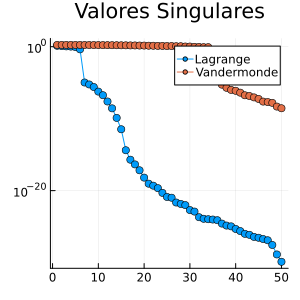

In [503]:
compare_bases(50, 100, 35, plot_flag= true, Chebyshev= true)

## Letra g )

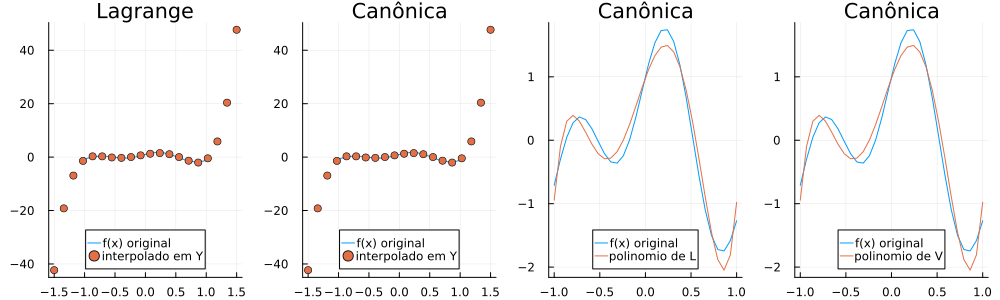

In [507]:
plot_interpolation(30, 20, 5, lim_y= (-1.5, 1.5))

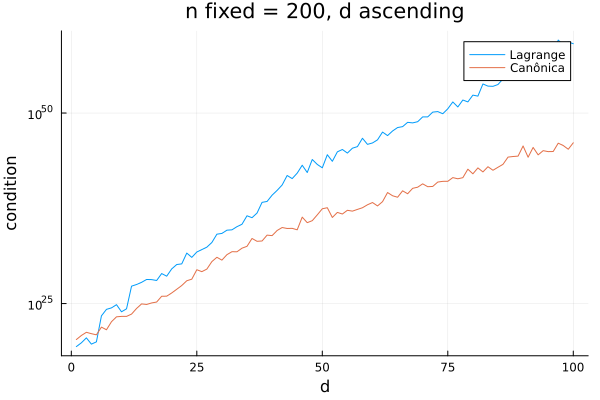

In [371]:
plot_condition_evaluated_bases(1000, 200, 100, variate_n= false, variate_d= true, logscale= true, lim_y= (-1.5,1.5))

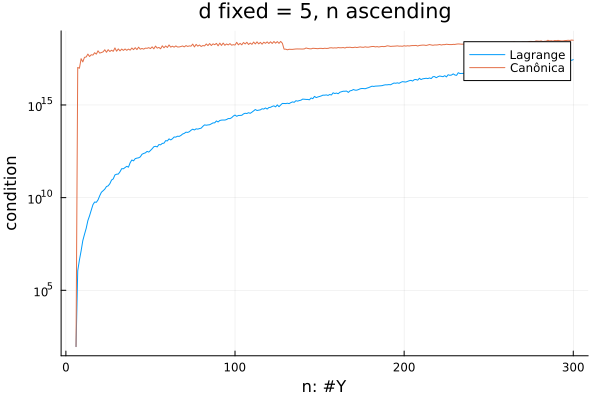

In [372]:
plot_condition_evaluated_bases(500, 300, 5, variate_n= true, variate_d= false, logscale= true, lim_y = (-1.5,1.5))

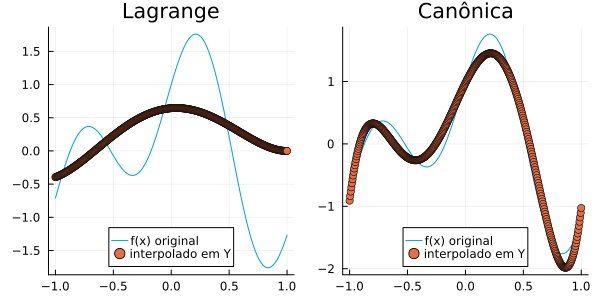

In [373]:
plot_interpolation(300, 400, 5, Chebyshev= true)

## Letra h )

## Letra i )

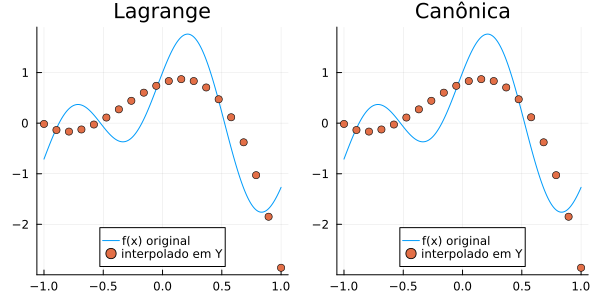

In [374]:
plot_interpolation(300, 20, 3)